In [134]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import types

In [104]:
def GaussianBlur(size, sigma):
  def result(img, _):
    return cv2.GaussianBlur(img, (size, size), sigma)
  return result

def MedianBlur(size):
  def result(img, _):
    return cv2.medianBlur(img, size)
  return result

def Sobel(size, scale):
  def result(img, _):
    grad_x = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=size, scale=scale)
    grad_y = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=size, scale=scale)
    return cv2.convertScaleAbs(grad_x) + cv2.convertScaleAbs(grad_y)
  return result

def CvtColor(code):
  def result(img, _):
    return cv2.cvtColor(img, code)
  return result



In [164]:
# Extra pipeline functions

def _iter_display_items(step, label_prefix):
  """Yield (label, image) pairs from a step, preserving Parallel branches."""
  if isinstance(step, list):
    for idx, item in enumerate(step, start=1):
      # Branch labels look like: Step 4.1, Step 4.2, ...
      yield from _iter_display_items(item, f"{label_prefix}.{idx}")
  else:
    yield label_prefix, step

def _pipeline_display_items(steps):
  items = []
  for step_idx, step in enumerate(steps, start=1):
    items.extend(_iter_display_items(step, f"Step {step_idx}"))
  return items

def RunPipeline(img, pipeline):
  result = [img]

  for command in pipeline:
    if isinstance(result[-1], list):
      results = []

      if isinstance(command, types.FunctionType) and "Aggregator" in command.__qualname__:
        results = command(None, result)
      elif isinstance(command, list):
        if len(command) != len(result[-1]):
          print(f"Error: Command list length {len(command)} does not match number of parallel branches {len(result[-1])}.")
          raise ValueError("Length of command list must match number of parallel branches.")
        
        for i in range(len(command)):
          results.append(command[i](result[-1][i], result))
      else:
        for im in result[-1]:
          results.append(command(im, result))

      result.append(results)
    else:
      result.append(command(result[-1], result))

  return result

def ShowAll(images, itemPerRow=3):
  if not images:
    return

  items = _pipeline_display_items(images)
  if not items:
    return

  cols = min(itemPerRow, len(items))
  rows = (len(items) + cols - 1) // cols

  fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))

  if rows == 1 and cols == 1:
    axes = [[axes]]
  elif rows == 1:
    axes = [axes]
  elif cols == 1:
    axes = [[ax] for ax in axes]

  for i in range(rows * cols):
    r, c = divmod(i, cols)
    ax = axes[r][c]
    if i < len(items):
      title, img = items[i]
      if len(img.shape) == 2:
        ax.imshow(img, cmap="gray")
      else:
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
      ax.set_title(title)
    ax.axis("off")

  fig.tight_layout()
  plt.show()

In [180]:
def RunCameraPipeline(
  pipeline,
  cameraIndex=0,
  itemPerRow=3,
  tileWidth=360,
  windowName="Camera Pipeline",
  resizableWindow=True,
  fitToWindow=True,
  minTileWidth=180,
  initialWindowSize=(1280, 720)
):
  def _letterbox_to_window(img, targetW, targetH):
    h, w = img.shape[:2]
    if targetW <= 0 or targetH <= 0 or w == 0 or h == 0:
      return img

    scale = min(targetW / w, targetH / h)
    newW = max(1, int(w * scale))
    newH = max(1, int(h * scale))
    resized = cv2.resize(img, (newW, newH), interpolation=cv2.INTER_AREA)

    canvas = np.zeros((targetH, targetW, 3), dtype=np.uint8)
    offX = (targetW - newW) // 2
    offY = (targetH - newH) // 2
    canvas[offY:offY + newH, offX:offX + newW] = resized
    return canvas

  windowFlags = cv2.WINDOW_NORMAL if resizableWindow else cv2.WINDOW_AUTOSIZE
  if resizableWindow and hasattr(cv2, "WINDOW_KEEPRATIO"):
    windowFlags |= cv2.WINDOW_KEEPRATIO

  cv2.namedWindow(windowName, windowFlags)
  if resizableWindow and initialWindowSize is not None:
    cv2.resizeWindow(windowName, initialWindowSize[0], initialWindowSize[1])

  cap = cv2.VideoCapture(cameraIndex)
  if not cap.isOpened():
    cv2.destroyWindow(windowName)
    raise RuntimeError(f"Could not open camera index {cameraIndex}")

  try:
    while True:
      ok, frame = cap.read()
      if not ok:
        break

      steps = RunPipeline(frame, pipeline)
      items = _pipeline_display_items(steps)
      if not items:
        continue

      cols = min(itemPerRow, len(items))
      targetTileWidth = max(minTileWidth, tileWidth)

      tiles = []
      for title, img in items:
        if img.ndim == 2:
          vis = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
        else:
          vis = img.copy()

        h, w = vis.shape[:2]
        tileHeight = max(1, int(h * (targetTileWidth / w)))
        vis = cv2.resize(vis, (targetTileWidth, tileHeight), interpolation=cv2.INTER_AREA)
        cv2.putText(vis, title, (10, 28), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)
        tiles.append(vis)

      rows = (len(tiles) + cols - 1) // cols

      blank = np.zeros_like(tiles[0])
      gridRows = []
      for r in range(rows):
        rowTiles = []
        for c in range(cols):
          idx = r * cols + c
          rowTiles.append(tiles[idx] if idx < len(tiles) else blank)
        gridRows.append(np.hstack(rowTiles))

      grid = np.vstack(gridRows)

      if resizableWindow and fitToWindow and hasattr(cv2, "getWindowImageRect"):
        try:
          _, _, windowW, windowH = cv2.getWindowImageRect(windowName)
          if windowW > 0 and windowH > 0:
            grid = _letterbox_to_window(grid, windowW, windowH)
        except cv2.error:
          pass

      cv2.imshow(windowName, grid)

      key = cv2.waitKey(1) & 0xFF
      if key in (27, ord("q")):  # ESC or q
        break
  finally:
    cap.release()
    cv2.destroyWindow(windowName)

In [107]:
def GenerateMask(amountOfAreas = 5):
  def result(img, _):
    if img.ndim == 3:
      img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    _, img = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    contours, _ = cv2.findContours(img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # images.append(contours)
    mask = np.zeros(img.shape, dtype=np.uint8)
    # get top n contours by area
    topContours = sorted(contours, key=cv2.contourArea, reverse=True)[:amountOfAreas]

    cv2.drawContours(mask, topContours, -1, 255, thickness=-1)
    return mask
  return result

In [204]:
from unittest import result


def Parallel(funcs: list):
  def result(img, prevs):
    results = []
    for func in funcs:
      results.append(func(img, prevs))
    return results
  return result

def UsePrevious(index):
  def result(img, previousResults):
    return previousResults[index]
  return result

def PassThrough():
  def result(img, _):
    return img
  return result

def AggregatorYIntoX(f = None, x: int = 0, y: list = [1]):
  def Aggregator(_, previousResults):
    # Flatten each selected branch output so the next list-command can map 1:1.
    imgs = []
    for i in y:
      branch_output = f(previousResults[-1][i])(previousResults[-1][x], previousResults)
      if isinstance(branch_output, list):
        imgs.extend(branch_output)
      else:
        imgs.append(branch_output)
    return imgs
  return Aggregator

def ParallelAggregable(funcs: list):
  def withMask(mask):
    def result(img, prevs):
      results = []
      for func in funcs:
        results.append(func(mask)(img, prevs))
      return results
    return result
  return withMask

def ApplyHueWithMask(new_hue):
    def withMask(mask):
      def result(img, _):
        h, s, v = cv2.split(img)
        h[mask == 255] = new_hue
        return cv2.merge([h, s, v])
      return result
    return withMask

In [109]:
img = cv2.imread("./images/20260314_115848.jpg", cv2.IMREAD_COLOR_BGR)

In [207]:
pipeline = [
  # MedianBlur(5),
  GaussianBlur(5, 1.2),
  Sobel(3, 2.0),
  # GaussianBlur(5, 1.2),
  Parallel([UsePrevious(-3), GenerateMask(1), GenerateMask(10), GenerateMask(30)]),
  [CvtColor(cv2.COLOR_RGB2HLS), PassThrough(), PassThrough(), PassThrough()],
  AggregatorYIntoX(ParallelAggregable([ApplyHueWithMask(0), ApplyHueWithMask(255)]), 0, [1, 2, 3]),
  [CvtColor(cv2.COLOR_HLS2RGB)] * 6,

]

In [208]:
RunCameraPipeline(pipeline, cameraIndex=0, itemPerRow=3, tileWidth=480, windowName="Camera Pipeline")

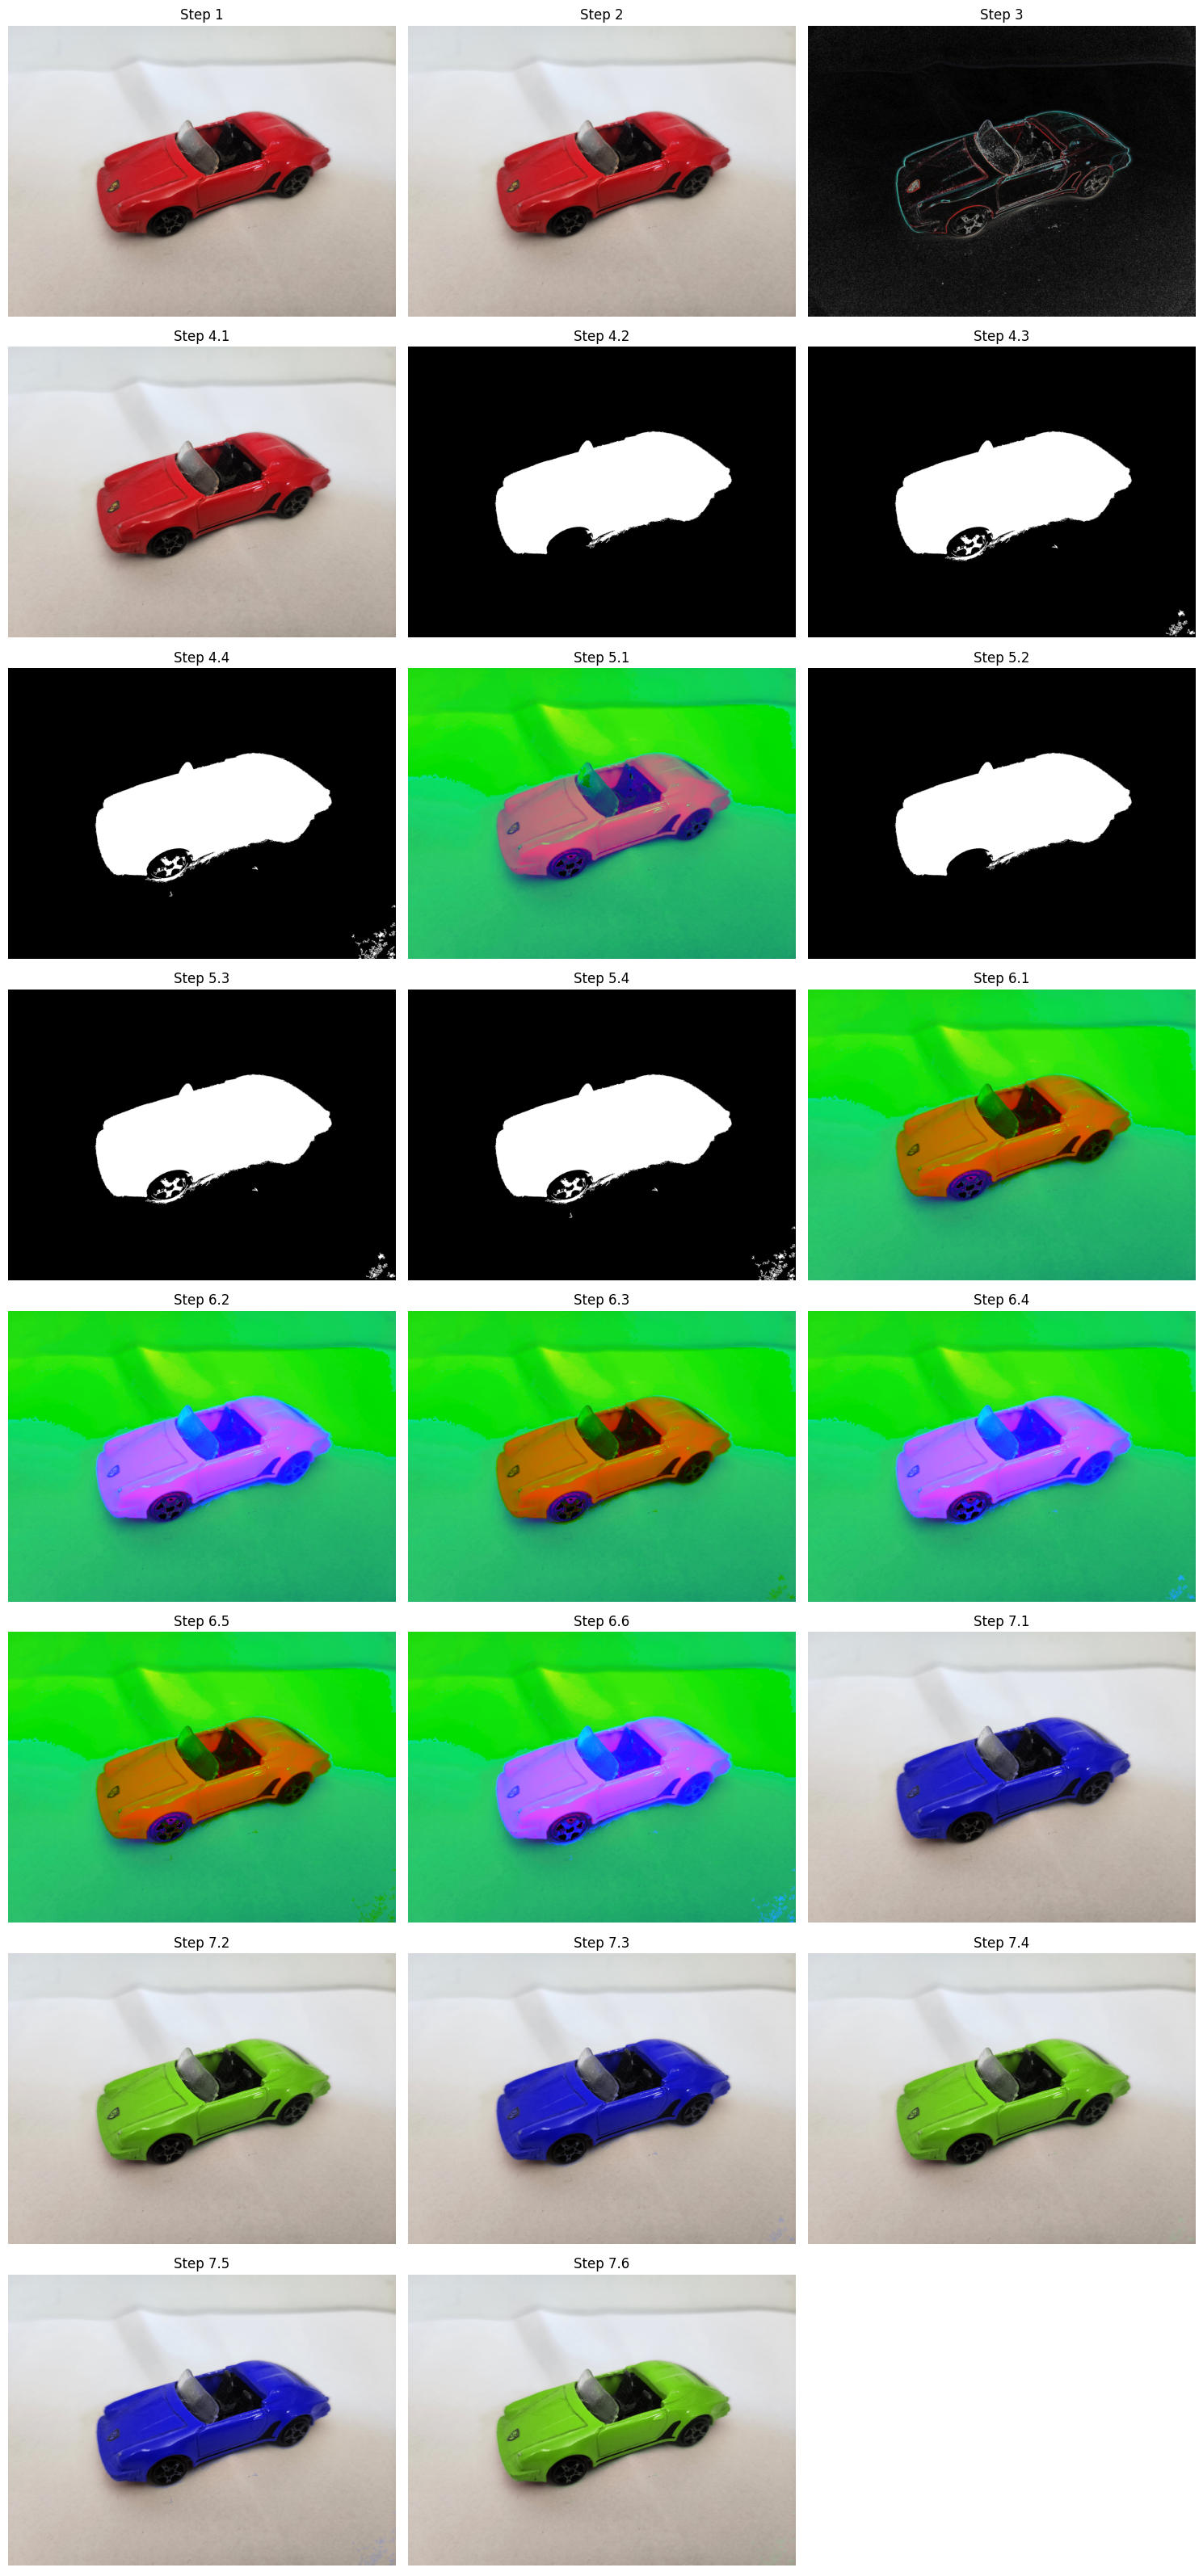

In [206]:
images = RunPipeline(img, pipeline)

ShowAll(images)



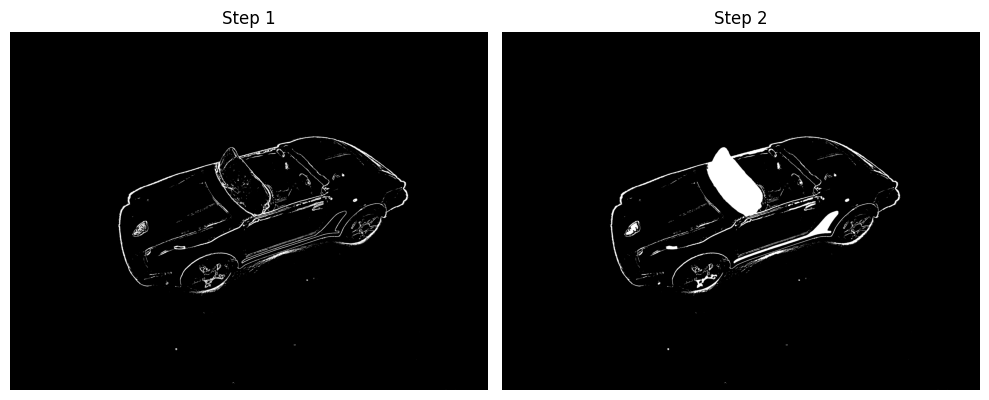

In [48]:
contour_img = images[-1]



ShowAll([contour_img, mask], itemPerRow=2)

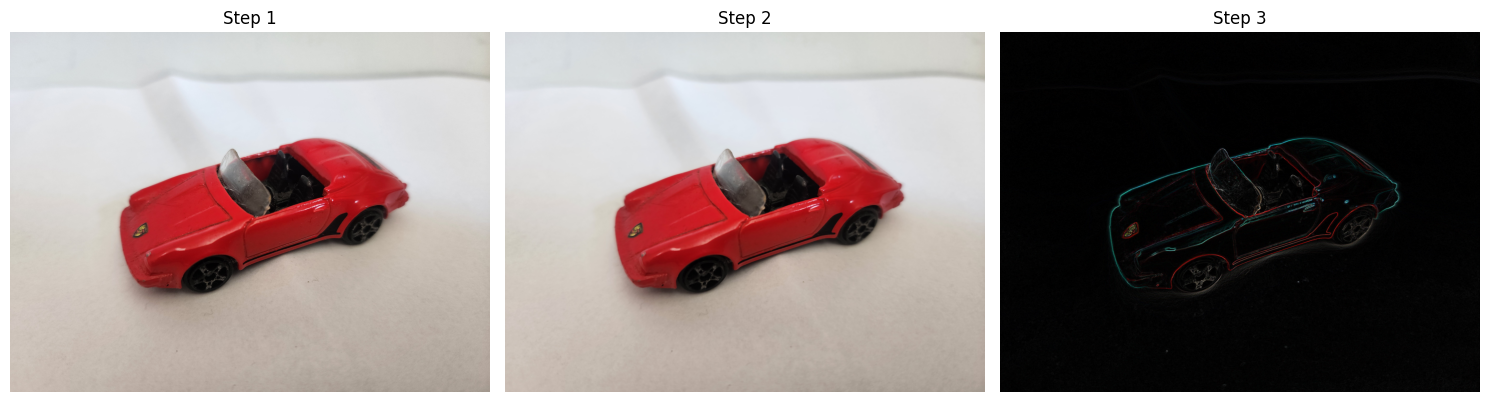

NameError: name 'gray' is not defined

In [45]:
ShowAll(images)

